## Library Import

In [ ]:
import random
import time
from collections import deque
import heapq
import statistics
import csv
from typing import List, Tuple, Optional, Dict
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation, PillowWriter

## Maze Generation

In [ ]:
def generate_maze_cells(rows: int, cols: int, seed: Optional[int] = None) -> List[List[str]]:
    """
    Generate a perfect maze using recursive backtracker.
    Input rows, cols refer to logical cells. Output grid size is (2*rows+1) x (2*cols+1)
    with '#' for walls and '.' for passages.
    """
    if seed is not None:
        random.seed(seed)
    H = 2 * rows + 1
    W = 2 * cols + 1
    grid = [['#'] * W for _ in range(H)]
    # Start cell at (1,1)
    stack = []
    start = (1, 1)
    grid[start[0]][start[1]] = '.'
    stack.append(start)
    visited = {start}
    directions = [(-2, 0), (2, 0), (0, -2), (0, 2)]
    while stack:
        r, c = stack[-1]
        neighbors = []
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if 1 <= nr < H - 1 and 1 <= nc < W - 1 and (nr, nc) not in visited:
                neighbors.append((nr, nc))
        if neighbors:
            nr, nc = random.choice(neighbors)
            # Carve wall between (r,c) and (nr,nc)
            wall_r, wall_c = (r + nr) // 2, (c + nc) // 2
            grid[wall_r][wall_c] = '.'
            grid[nr][nc] = '.'
            visited.add((nr, nc))
            stack.append((nr, nc))
        else:
            stack.pop()
    return grid

## Path Finding Algorithm

In [ ]:
def neighbors_4(grid: List[List[str]], node: Tuple[int, int]):
    H = len(grid)
    W = len(grid[0])
    r, c = node
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        nr, nc = r+dr, c+dc
        if 0 <= nr < H and 0 <= nc < W and grid[nr][nc] != '#':
            yield (nr, nc)

def reconstruct_path(parent: Dict[Tuple[int,int], Tuple[int,int]],
                     start: Tuple[int,int],
                     goal: Tuple[int,int]) -> List[Tuple[int,int]]:
    path = []
    node = goal
    while node != start:
        path.append(node)
        node = parent.get(node)
        if node is None:
            return []
    path.append(start)
    path.reverse()
    return path

### BFS

In [ ]:
def bfs_search(grid: List[List[str]], start: Tuple[int,int], goal: Tuple[int,int]):
    t0 = time.perf_counter()
    frontier = deque([start])
    parent = {start: None}
    visited = {start}
    visited_order = [start]
    nodes_expanded = 0
    max_frontier = 1
    found = False
    while frontier:
        node = frontier.popleft()
        nodes_expanded += 1
        if node == goal:
            found = True
            break
        for nb in neighbors_4(grid, node):
            if nb not in visited:
                visited.add(nb)
                parent[nb] = node
                frontier.append(nb)
                # enqueue == discovered
                visited_order.append(nb)
        if len(frontier) > max_frontier:
            max_frontier = len(frontier)
    path = reconstruct_path(parent, start, goal) if found else []
    t1 = time.perf_counter()
    return {
        'found': found,
        'time': t1 - t0,
        'nodes_expanded': nodes_expanded,
        'max_frontier': max_frontier,
        'path_length': len(path)-1 if found else None,
        'path': path,
        'visited_order': visited_order
    }

### DFS

In [ ]:
def dfs_search(grid: List[List[str]], start: Tuple[int,int], goal: Tuple[int,int]):
    t0 = time.perf_counter()
    frontier = [start]
    parent = {start: None}
    visited = {start}
    visited_order = [start]
    nodes_expanded = 0
    max_frontier = 1
    found = False
    while frontier:
        node = frontier.pop()
        nodes_expanded += 1
        if node == goal:
            found = True
            break
        for nb in neighbors_4(grid, node):
            if nb not in visited:
                visited.add(nb)
                parent[nb] = node
                frontier.append(nb)
                visited_order.append(nb)
        if len(frontier) > max_frontier:
            max_frontier = len(frontier)
    path = reconstruct_path(parent, start, goal) if found else []
    t1 = time.perf_counter()
    return {
        'found': found,
        'time': t1 - t0,
        'nodes_expanded': nodes_expanded,
        'max_frontier': max_frontier,
        'path_length': len(path)-1 if found else None,
        'path': path,
        'visited_order': visited_order
    }

### A*

In [ ]:
def manhattan(a: Tuple[int,int], b: Tuple[int,int]) -> int:
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def astar_search(grid: List[List[str]], start: Tuple[int,int], goal: Tuple[int,int]):
    t0 = time.perf_counter()
    counter = 0
    frontier = []
    g_score = {start: 0}
    f0 = manhattan(start, goal)
    heapq.heappush(frontier, (f0, counter, start))
    parent = {start: None}
    closed = set()
    visited_order = [start]
    nodes_expanded = 0
    max_frontier = 1
    found = False
    while frontier:
        f, _, node = heapq.heappop(frontier)
        if node in closed:
            continue
        closed.add(node)
        nodes_expanded += 1
        if node == goal:
            found = True
            break
        for nb in neighbors_4(grid, node):
            tentative_g = g_score[node] + 1
            if nb in closed and tentative_g >= g_score.get(nb, float('inf')):
                continue
            if tentative_g < g_score.get(nb, float('inf')):
                parent[nb] = node
                g_score[nb] = tentative_g
                counter += 1
                heapq.heappush(frontier, (tentative_g + manhattan(nb, goal), counter, nb))
                visited_order.append(nb)
        if len(frontier) > max_frontier:
            max_frontier = len(frontier)
    path = reconstruct_path(parent, start, goal) if found else []
    t1 = time.perf_counter()
    return {
        'found': found,
        'time': t1 - t0,
        'nodes_expanded': nodes_expanded,
        'max_frontier': max_frontier,
        'path_length': len(path)-1 if found else None,
        'path': path,
        'visited_order': visited_order
    }

## Overlay Path and Print Maze

In [ ]:
def overlay_path(grid: List[List[str]], path: List[Tuple[int,int]], start: Tuple[int,int], goal: Tuple[int,int]) -> List[List[str]]:
    g2 = [row[:] for row in grid]
    for r, c in path:
        if (r, c) != start and (r, c) != goal:
            g2[r][c] = '*'
    sr, sc = start
    gr, gc = goal
    g2[sr][sc] = 'S'
    g2[gr][gc] = 'G'
    return g2

def print_grid(grid: List[List[str]]):
    for row in grid:
        print(''.join(row))

## Run Single Trail

In [ ]:
def run_single_maze_and_alg(rows: int, cols: int, algorithm: str, seed: Optional[int] = None):
    grid = generate_maze_cells(rows, cols, seed=seed)
    start = (1, 1)
    goal = (2*rows - 1, 2*cols - 1)
    if grid[start[0]][start[1]] == '#' or grid[goal[0]][goal[1]] == '#':
        grid[start[0]][start[1]] = '.'
        grid[goal[0]][goal[1]] = '.'
    if algorithm == 'bfs':
        result = bfs_search(grid, start, goal)
    elif algorithm == 'dfs':
        result = dfs_search(grid, start, goal)
    elif algorithm == 'astar':
        result = astar_search(grid, start, goal)
    else:
        raise ValueError("Unknown algorithm: " + algorithm)
    result['grid'] = grid
    result['start'] = start
    result['goal'] = goal
    return result

## Multiple Trials Across Sizes and Algorithms

In [ ]:
def run_experiments(sizes: List[int], trials_per_size: int = 20, algorithms: List[str] = ['bfs','dfs','astar'], seeds: Optional[List[int]] = None, max_examples_to_show: int = 1):
    """
    Returns dict keyed by (size, algorithm) -> list of entry dicts.
    For the first `max_examples_to_show` trials, entries also include grid/path/start/goal/visited_order for visualization.
    """
    all_results = {}
    for N in sizes:
        print(f"\n=== Size (logical cells): {N} x {N} => character-grid: {2*N+1} x {2*N+1} ===")
        for alg in algorithms:
            all_results[(N, alg)] = []
        for t in range(trials_per_size):
            seed = None
            if seeds is not None and t < len(seeds):
                seed = seeds[t]
            grid = generate_maze_cells(N, N, seed=seed)
            start = (1,1)
            goal = (2*N - 1, 2*N - 1)
            grid[start[0]][start[1]] = '.'
            grid[goal[0]][goal[1]] = '.'
            for alg in algorithms:
                if alg == 'bfs':
                    res = bfs_search(grid, start, goal)
                elif alg == 'dfs':
                    res = dfs_search(grid, start, goal)
                elif alg == 'astar':
                    res = astar_search(grid, start, goal)
                else:
                    raise ValueError("Unknown algorithm: " + alg)
                entry = {k: res[k] for k in ['found','time','nodes_expanded','max_frontier','path_length']}
                if t < max_examples_to_show:
                    entry['grid'] = grid
                    entry['path'] = res.get('path', [])
                    entry['start'] = start
                    entry['goal'] = goal
                    entry['visited_order'] = res.get('visited_order', [])
                all_results[(N,alg)].append(entry)
        # print summary
        print("\nSummary (averages over trials):")
        header = f"{'Alg':6} {'Trials':>6} {'SuccRate':>8} {'AvgTime(s)':>12} {'AvgNodes':>12} {'AvgMaxFront':>12} {'AvgPathLen':>12}"
        print(header)

        for alg in algorithms:
            entries = all_results[(N,alg)]
            trials_run = len(entries)
            succ = [1 if e['found'] else 0 for e in entries]
            times = [e['time'] for e in entries]
            nodes = [e['nodes_expanded'] for e in entries]
            fronts = [e['max_frontier'] for e in entries]
            pathlens = [e['path_length'] for e in entries if e['path_length'] is not None]
            succ_rate = sum(succ)/trials_run
            avg_time = statistics.mean(times)
            avg_nodes = statistics.mean(nodes)
            avg_front = statistics.mean(fronts)
            avg_pathlen = statistics.mean(pathlens) if pathlens else None
            print(f"{alg:6} {trials_run:6} {succ_rate:8.2f} {avg_time:12.6f} {avg_nodes:12.2f} {avg_front:12.2f} {str(avg_pathlen):>12}")

        for alg in algorithms:
            sample = all_results[(N,alg)][0]
            print(f"\nExample: Algorithm={alg}, Size={N} (one sample maze)")
            grid = sample.get('grid')
            path = sample.get('path', [])
            if grid and path is not None:
                overlay = overlay_path(grid, path, sample['start'], sample['goal'])
                print_grid(overlay)
                print(f"Found: {sample['found']}, Time: {sample['time']:.6f}s, Nodes: {sample['nodes_expanded']}, MaxFrontier: {sample['max_frontier']}, PathLen: {sample['path_length']}")
    return all_results

## Visualisation

In [ ]:
_TILE_CMAP = ListedColormap([
    "#f8fafc",  # floor
    "#111827",  # wall
    "#93c5fd",  # explored
    "#2563eb",  # path
    "#22c55e",  # start
    "#ef4444",  # goal
])

def _grid_to_base_layers(grid: List[List[str]],
                         start: Optional[Tuple[int,int]] = None,
                         goal: Optional[Tuple[int,int]] = None) -> np.ndarray:
    H = len(grid)
    W = len(grid[0]) if H else 0
    arr = np.zeros((H, W), dtype=np.uint8)
    for r in range(H):
        for c in range(W):
            ch = grid[r][c]
            arr[r, c] = 1 if ch in ("#", "█", "X") else 0
    if start:
        arr[start[0], start[1]] = 4
    if goal:
        arr[goal[0], goal[1]] = 5
    return arr

def _overlay_explored(arr: np.ndarray, explored_cells: List[Tuple[int,int]]):
    H, W = arr.shape
    for (r, c) in explored_cells:
        if 0 <= r < H and 0 <= c < W:
            if arr[r, c] in (0, 3):
                arr[r, c] = 2

def _overlay_path(arr: np.ndarray, path: List[Tuple[int,int]]):
    H, W = arr.shape
    for (r, c) in path:
        if 0 <= r < H and 0 <= c < W:
            if arr[r, c] not in (4, 5):
                arr[r, c] = 3

def render_static(grid: List[List[str]],
                  path: Optional[List[Tuple[int,int]]] = None,
                  start: Optional[Tuple[int,int]] = None,
                  goal: Optional[Tuple[int,int]] = None,
                  explored: Optional[List[Tuple[int,int]]] = None,
                  title: str = "Maze"):
    base = _grid_to_base_layers(grid, start, goal)
    if explored:
        _overlay_explored(base, explored)
    if path:
        _overlay_path(base, path)
    plt.figure(figsize=(6, 6))
    plt.imshow(base, cmap=_TILE_CMAP, interpolation="nearest")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def animate_solution(grid: List[List[str]],
                     path: List[Tuple[int,int]],
                     start: Optional[Tuple[int,int]] = None,
                     goal: Optional[Tuple[int,int]] = None,
                     explored: Optional[List[Tuple[int,int]]] = None,
                     fps: int = 25,
                     cell_grid: bool = True,
                     save_gif: Optional[str] = None,
                     save_mp4: Optional[str] = None):
    base = _grid_to_base_layers(grid, start, goal)
    H, W = base.shape
    fig, ax = plt.subplots(figsize=(6,6))
    img = ax.imshow(base, cmap=_TILE_CMAP, interpolation="nearest", animated=True)
    ax.set_title("Maze – search + solution")
    ax.axis("off")
    if cell_grid:
        ax.set_xticks(np.arange(-.5, W, 1), minor=True)
        ax.set_yticks(np.arange(-.5, H, 1), minor=True)
        ax.grid(which="minor", color="#e5e7eb", linestyle="-", linewidth=0.5)
        ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    agent_dot, = ax.plot([], [], marker="o", markersize=8, linestyle="None", alpha=0.95, zorder=10, color="#0ea5e9")

    frames = []
    if explored:
        frames.extend([("explored", i) for i in range(len(explored))])
    frames.extend([("path", i) for i in range(len(path))])

    explored_prefix: List[Tuple[int,int]] = []
    path_prefix: List[Tuple[int,int]] = []

    def _update(idx):
        phase, i = frames[idx]
        arr = base.copy()
        if explored:
            if phase == "explored":
                explored_prefix.append(explored[i])
            _overlay_explored(arr, explored_prefix)
        if phase == "path":
            path_prefix.append(path[i])
        if path_prefix:
            _overlay_path(arr, path_prefix)
        img.set_array(arr)
        # agent position
        if path_prefix:
            r, c = path_prefix[-1]
        else:
            r, c = (start if start else path[0])
        agent_dot.set_data([c], [r])
        return (img, agent_dot)

    interval_ms = int(1000 / max(1, fps))
    anim = FuncAnimation(fig, _update, frames=len(frames), interval=interval_ms, blit=True)
    plt.close(fig)

    if save_gif:
        try:
            anim.save(save_gif, writer=PillowWriter(fps=fps))
            print(f"Saved GIF: {save_gif}")
        except Exception as e:
            print("GIF save failed (need Pillow):", e)
    if save_mp4:
        try:
            anim.save(save_mp4, fps=fps, dpi=150)
            print(f"Saved MP4: {save_mp4}")
        except Exception as e:
            print("MP4 save failed (need ffmpeg):", e)

    return anim

def visualize_examples_from_results(all_results: Dict[Tuple[int,str], List[dict]],
                                    size: int,
                                    algorithms: Optional[List[str]] = None,
                                    max_per_alg: int = 1):
    keys = [(N, alg) for (N, alg) in all_results.keys() if N == size]
    if algorithms:
        keys = [(N, alg) for (N, alg) in keys if alg in algorithms]
    if not keys:
        print(f"No results for size={size}")
        return
    for (N, alg) in keys:
        shown = 0
        for sample in all_results[(N, alg)]:
            if "grid" in sample and "path" in sample:
                title = f"{alg.upper()} | size {N}"
                render_static(sample["grid"], sample["path"], sample.get("start"), sample.get("goal"),
                              sample.get("visited_order"), title=title)
                shown += 1
                if shown >= max_per_alg:
                    break


def experiments_to_dataframe(all_results: Dict[Tuple[int, str], List[dict]]) -> pd.DataFrame:
    rows = []
    for (size, alg), entries in all_results.items():
        for t, e in enumerate(entries):
            rows.append({
                "size": size,
                "algorithm": alg,
                "trial": t,
                "found": bool(e.get("found")),
                "time": e.get("time", math.nan),
                "nodes_expanded": e.get("nodes_expanded", math.nan),
                "max_frontier": e.get("max_frontier", math.nan),
                "path_length": e.get("path_length", math.nan),
            })
    df = pd.DataFrame(rows)
    df["algorithm"] = df["algorithm"].astype("category")
    return df

def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    metrics = ["time","nodes_expanded","max_frontier","path_length"]
    agg = {m: ["mean","std"] for m in metrics}
    agg["found"] = ["mean"]
    summary = df.groupby(["size","algorithm"], observed=True).agg(agg)
    summary.columns = ["_".join([c for c in col if c]) for col in summary.columns.values]
    summary = summary.reset_index()
    return summary

def _grouped_bar(ax, data, sizes, title, ylabel):
    algos = list(data["algorithm"].cat.categories if hasattr(data["algorithm"], "cat")
                 else sorted(data["algorithm"].unique()))
    x = range(len(sizes))
    width = 0.8 / max(1, len(algos))
    for i, alg in enumerate(algos):
        sub = data[data["algorithm"] == alg]
        y = [sub.loc[sub["size"] == s, "value"].values[0] if (sub["size"]==s).any() else float('nan')
             for s in sizes]
        ax.bar([xi + i*width - 0.4 + width/2 for xi in x], y,
               width=width, label=str(alg))

    ax.set_xticks(list(x))
    ax.set_xticklabels([f"N={s}" for s in sizes])

    ax.set_xlabel("Maze size (logical N)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.text(1.0, -0.18, f"Logical N shown: {', '.join(map(str, sizes))}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9)


def plot_metric(summary: pd.DataFrame, metric: str, title: str, ylabel: str):
    col = f"{metric}_mean"
    if col not in summary.columns:
        raise ValueError(f"'{col}' not in summary.")
    plot_df = summary[["size","algorithm", col]].rename(columns={col:"value"}).copy()
    plot_df["algorithm"] = plot_df["algorithm"].astype("category")
    sizes = sorted(plot_df["size"].unique())
    fig, ax = plt.subplots()
    _grouped_bar(ax, plot_df, sizes, title, ylabel)
    plt.tight_layout()
    plt.show()

def plot_all(summary: pd.DataFrame, *, save_prefix: str | None = None):
    labels = {
        "time": ("Solve Time", "Seconds"),
        "nodes_expanded": ("Nodes Expanded", "Count"),
        "max_frontier": ("Max Frontier Size", "Count"),
        "path_length": ("Path Length", "Steps"),
        "found": ("Success Rate (Found)", "Proportion found"),
    }
    for m, (title, ylabel) in labels.items():
        col = f"{m}_mean"
        if col in summary.columns:
            plot_metric(summary, m, title, ylabel)
            if save_prefix is not None:
                plt.gcf().savefig(f"{save_prefix}_{m}.png", dpi=150)

## Single Run Demo

To save time now it's running with small trails. Please do these changes for the full feldge run.
For the full project, set trials_per_size=20 and sizes=list(range(5, 51, 5)).

Demo run: logical size 20 x 20 (char-grid 41x41), algorithm=bfs
#########################################
#S#***#***#***********#.....#........***#
#*#*#*#*#*#*#########*#.#####.#######*#*#
#*#*#*#*#*#***#*****#*#.#...#.#...#***#*#
#*#*#*#*#*###*#*###*#*#.#.#.#.#.#.#*###*#
#***#***#*#***#***#***#...#.....#.#*#.#*#
#########*#*#####*#####.#######.###*#.#*#
#.......#***#...#*****#...#***#.#***#***#
#.#####.#######.#####*#####*#*###*###*###
#...#.#.........#...#***#***#*****#***#.#
###.#.#.#######.###.###*#*#########*###.#
#...#.#...#...#.#.....#***#.......#*#...#
#.###.###.#.#.#.#.###.#####.###.###*#.#.#
#.#.....#.#.#.#...#.#.#...#.#...#***#.#.#
#.#####.#.#.#.#####.#.#.#.#.#.#.#*###.#.#
#...#...#.#.#...#...#.#.#.#.#.#.#*#...#.#
###.#.#.#.#.###.#.#.#.###.#.#.#.#*###.#.#
#.....#.#.#.#...#.#.#...#...#.#.#***#.#.#
#.#######.#.###.#.#####.#####.#.###*###.#
#.#.#.....#...#...#.....#.....#...#*****#
#.#.#.#####.#.#####.#####.###.#########*#
#...#.#.....#...#.........#...#*****..#*#
###.#.#.####

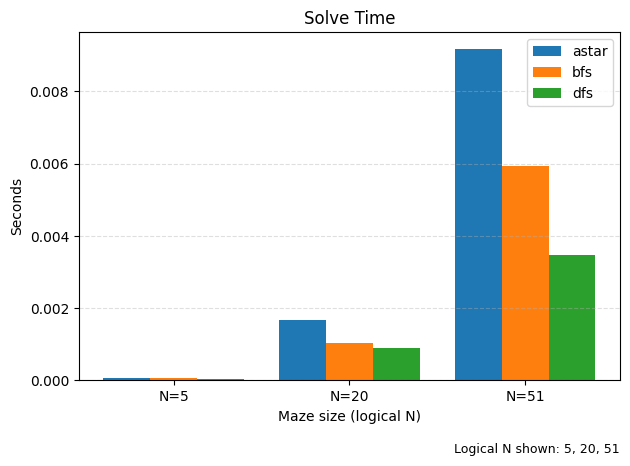

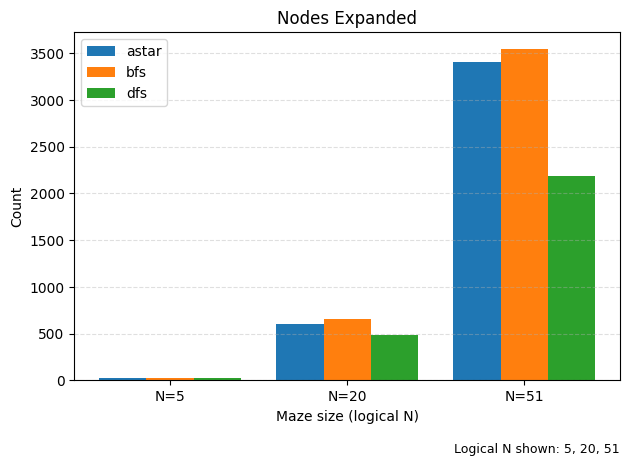

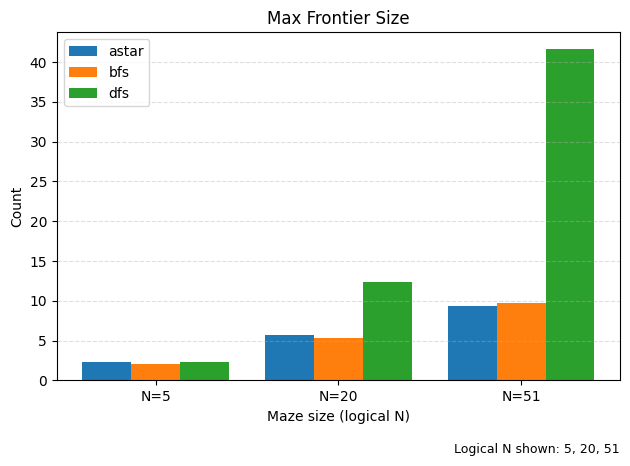

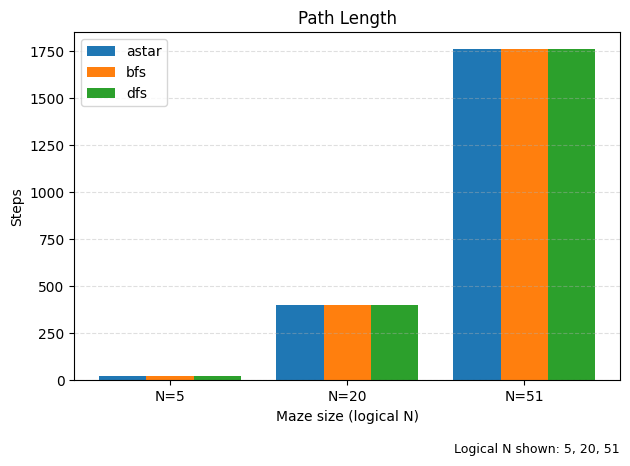

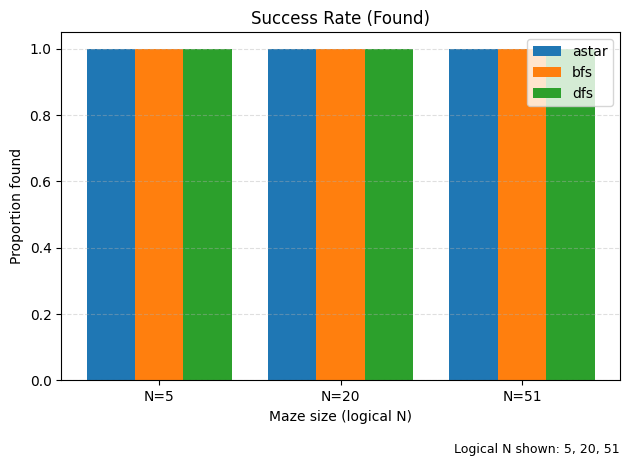

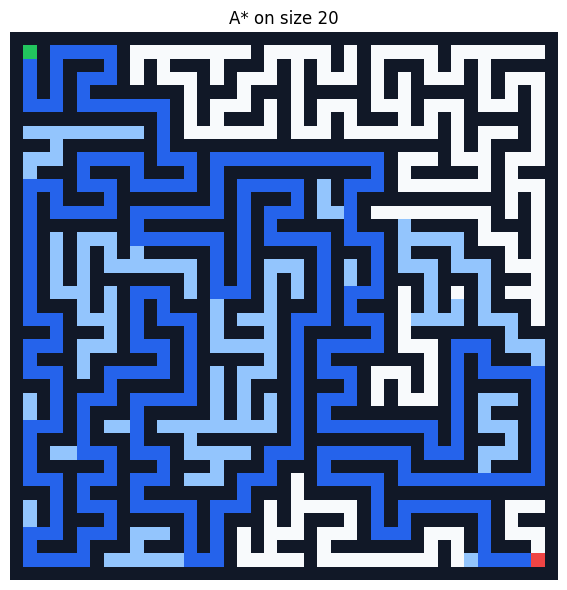

In [ ]:
def demo_one_run(size=7, algorithm='astar', seed=None):
    print(f"Demo run: logical size {size} x {size} (char-grid {(2*size+1)}x{(2*size+1)}), algorithm={algorithm}")
    res = run_single_maze_and_alg(size, size, algorithm, seed=seed)
    grid = res['grid']
    path = res['path']
    overlay = overlay_path(grid, path, res['start'], res['goal'])
    print_grid(overlay)
    print("\nMetrics:")
    print(f"Found: {res['found']}")
    print(f"Time: {res['time']:.6f} s")
    print(f"Nodes Expanded: {res['nodes_expanded']}")
    print(f"Max Frontier Size: {res['max_frontier']}")
    print(f"Path Length (steps): {res['path_length']}")

# ===== main =====
if __name__ == "__main__":
    demo_one_run(size=20, algorithm='bfs', seed=42)
    print("\n---\n")
    demo_one_run(size=20, algorithm='dfs', seed=42)
    print("\n---\n")
    demo_one_run(size=20, algorithm='astar', seed=42)


    sizes_demo = [5, 20, 51]
    all_results = run_experiments(
        sizes=sizes_demo,
        trials_per_size=3,
        algorithms=['bfs','dfs','astar'],
        max_examples_to_show=1
    )


    df = experiments_to_dataframe(all_results)
    summary = summarize_results(df)
    print("\nTidy summary (first rows):\n", summary.head(8).to_string(index=False))
    plot_all(summary)


    sample = all_results[(20, 'astar')][0]

    render_static(sample['grid'], path=sample['path'],
                  start=sample.get('start'), goal=sample.get('goal'),
                  explored=sample.get('visited_order'), title="A* on size 20")


    anim = animate_solution(sample['grid'], sample['path'],
                            start=sample.get('start'), goal=sample.get('goal'),
                            explored=sample.get('visited_order'),
                            fps=25, cell_grid=True,
                            save_gif=None,
                            save_mp4=None)


I have to check how this algorithm works in non detesministic enviroment to see the optimization works good or bad.

Demo run: logical size 20 x 20 (char-grid 41x41), algorithm=bfs
#########################################
#S#***#***#***********#.....#........***#
#*#*#*#*#*#*#########*#.#####.#######*#*#
#*#*#*#*#*#***#*****#*#.#...#.#...#***#*#
#*#*#*#*#*###*#*###*#*#.#.#.#.#.#.#*###*#
#***#***#*#***#***#***#...#.....#.#*#.#*#
#########*#*#####*#####.#######.###*#.#*#
#.......#***#...#*****#...#***#.#***#***#
#.#####.#######.#####*#####*#*###*###*###
#...#.#.........#...#***#***#*****#***#.#
###.#.#.#######.###.###*#*#########*###.#
#...#.#...#...#.#.....#***#.......#*#...#
#.###.###.#.#.#.#.###.#####.###.###*#.#.#
#.#.....#.#.#.#...#.#.#...#.#...#***#.#.#
#.#####.#.#.#.#####.#.#.#.#.#.#.#*###.#.#
#...#...#.#.#...#...#.#.#.#.#.#.#*#...#.#
###.#.#.#.#.###.#.#.#.###.#.#.#.#*###.#.#
#.....#.#.#.#...#.#.#...#...#.#.#***#.#.#
#.#######.#.###.#.#####.#####.#.###*###.#
#.#.#.....#...#...#.....#.....#...#*****#
#.#.#.#####.#.#####.#####.###.#########*#
#...#.#.....#...#.........#...#*****..#*#
###.#.#.####

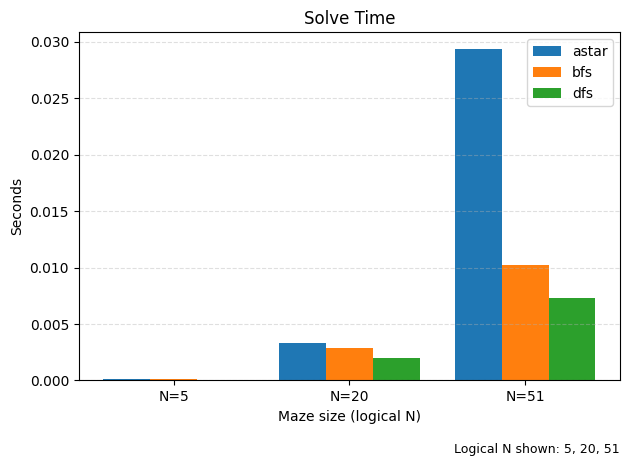

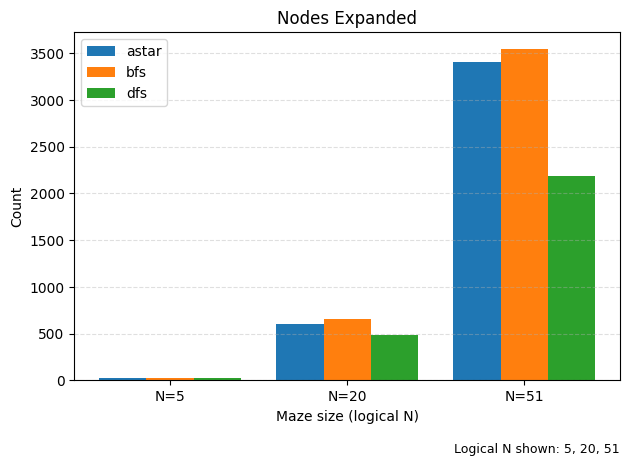

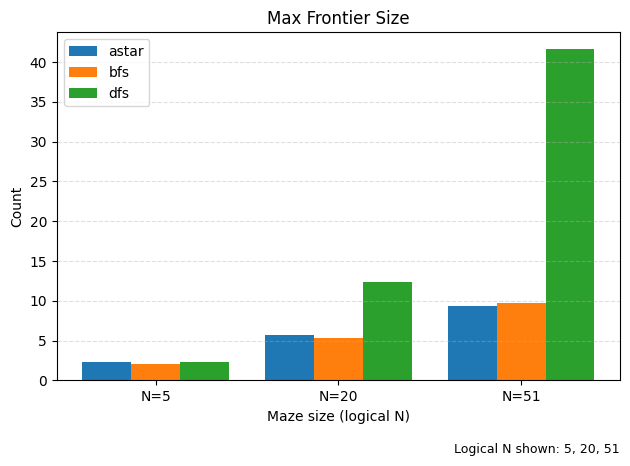

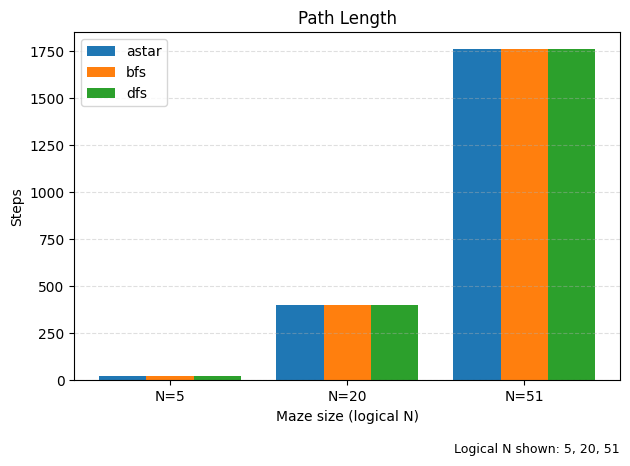

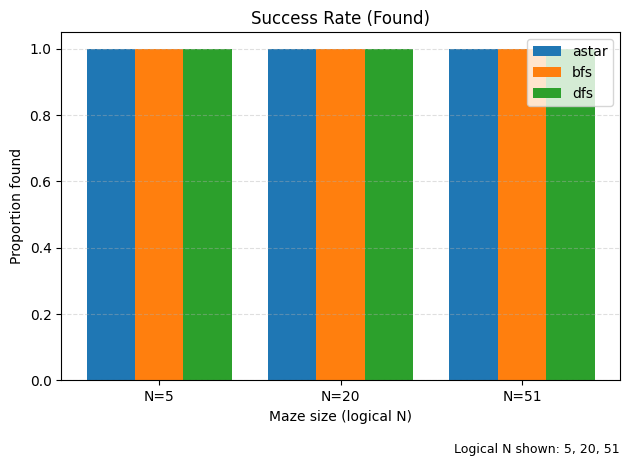

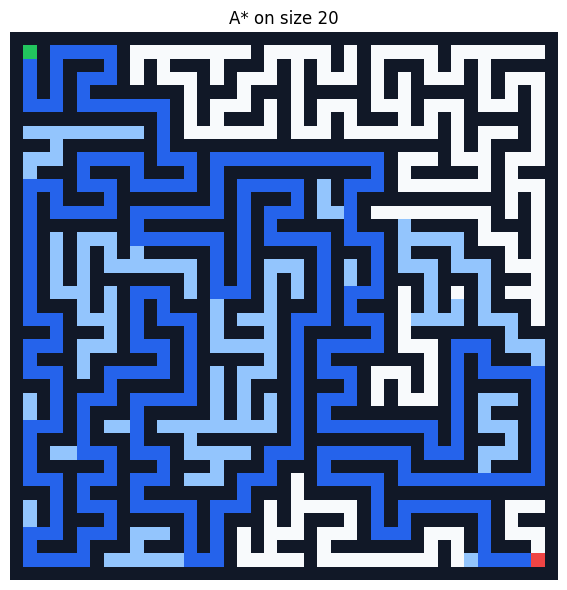

In [ ]:
# Pathfinding experiments: BFS, DFS, A* on generated mazes
# Standard-library only for algorithms; viz uses numpy/matplotlib/pandas
import random
import time
from collections import deque
import heapq
import statistics
import csv
from typing import List, Tuple, Optional, Dict

# --- extra imports for visualization & charts ---
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation, PillowWriter

# -------------------------
# Maze generation (recursive backtracker)
# -------------------------
def generate_maze_cells(rows: int, cols: int, seed: Optional[int] = None) -> List[List[str]]:
    """
    Generate a perfect maze using recursive backtracker.
    Input rows, cols refer to logical cells. Output grid size is (2*rows+1) x (2*cols+1)
    with '#' for walls and '.' for passages.
    """
    if seed is not None:
        random.seed(seed)
    H = 2 * rows + 1
    W = 2 * cols + 1
    grid = [['#'] * W for _ in range(H)]
    # Start cell at (1,1)
    stack = []
    start = (1, 1)
    grid[start[0]][start[1]] = '.'
    stack.append(start)
    visited = {start}
    directions = [(-2, 0), (2, 0), (0, -2), (0, 2)]  # moves to neighbor cells (two steps)
    while stack:
        r, c = stack[-1]
        neighbors = []
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if 1 <= nr < H - 1 and 1 <= nc < W - 1 and (nr, nc) not in visited:
                neighbors.append((nr, nc))
        if neighbors:
            nr, nc = random.choice(neighbors)
            # Carve wall between (r,c) and (nr,nc)
            wall_r, wall_c = (r + nr) // 2, (c + nc) // 2
            grid[wall_r][wall_c] = '.'
            grid[nr][nc] = '.'
            visited.add((nr, nc))
            stack.append((nr, nc))
        else:
            stack.pop()
    return grid

# -------------------------
# Pathfinding algorithms (now record exploration order for animation)
# -------------------------
def neighbors_4(grid: List[List[str]], node: Tuple[int, int]):
    H = len(grid)
    W = len(grid[0])
    r, c = node
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        nr, nc = r+dr, c+dc
        if 0 <= nr < H and 0 <= nc < W and grid[nr][nc] != '#':
            yield (nr, nc)

def reconstruct_path(parent: Dict[Tuple[int,int], Tuple[int,int]],
                     start: Tuple[int,int],
                     goal: Tuple[int,int]) -> List[Tuple[int,int]]:
    path = []
    node = goal
    while node != start:
        path.append(node)
        node = parent.get(node)
        if node is None:
            return []
    path.append(start)
    path.reverse()
    return path

def bfs_search(grid: List[List[str]], start: Tuple[int,int], goal: Tuple[int,int]):
    t0 = time.perf_counter()
    frontier = deque([start])
    parent = {start: None}
    visited = {start}
    visited_order = [start]          # NEW: exploration playback
    nodes_expanded = 0
    max_frontier = 1
    found = False
    while frontier:
        node = frontier.popleft()
        nodes_expanded += 1
        if node == goal:
            found = True
            break
        for nb in neighbors_4(grid, node):
            if nb not in visited:
                visited.add(nb)
                parent[nb] = node
                frontier.append(nb)
                visited_order.append(nb)   # enqueue == discovered
        if len(frontier) > max_frontier:
            max_frontier = len(frontier)
    path = reconstruct_path(parent, start, goal) if found else []
    t1 = time.perf_counter()
    return {
        'found': found,
        'time': t1 - t0,
        'nodes_expanded': nodes_expanded,
        'max_frontier': max_frontier,
        'path_length': len(path)-1 if found else None,
        'path': path,
        'visited_order': visited_order
    }

def dfs_search(grid: List[List[str]], start: Tuple[int,int], goal: Tuple[int,int]):
    t0 = time.perf_counter()
    frontier = [start]  # stack
    parent = {start: None}
    visited = {start}
    visited_order = [start]
    nodes_expanded = 0
    max_frontier = 1
    found = False
    while frontier:
        node = frontier.pop()
        nodes_expanded += 1
        if node == goal:
            found = True
            break
        for nb in neighbors_4(grid, node):
            if nb not in visited:
                visited.add(nb)
                parent[nb] = node
                frontier.append(nb)
                visited_order.append(nb)
        if len(frontier) > max_frontier:
            max_frontier = len(frontier)
    path = reconstruct_path(parent, start, goal) if found else []
    t1 = time.perf_counter()
    return {
        'found': found,
        'time': t1 - t0,
        'nodes_expanded': nodes_expanded,
        'max_frontier': max_frontier,
        'path_length': len(path)-1 if found else None,
        'path': path,
        'visited_order': visited_order
    }

def manhattan(a: Tuple[int,int], b: Tuple[int,int]) -> int:
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def astar_search(grid: List[List[str]], start: Tuple[int,int], goal: Tuple[int,int]):
    t0 = time.perf_counter()
    counter = 0
    frontier = []
    g_score = {start: 0}
    f0 = manhattan(start, goal)
    heapq.heappush(frontier, (f0, counter, start))
    parent = {start: None}
    closed = set()
    visited_order = [start]
    nodes_expanded = 0
    max_frontier = 1
    found = False
    while frontier:
        f, _, node = heapq.heappop(frontier)
        if node in closed:
            continue
        closed.add(node)
        nodes_expanded += 1
        if node == goal:
            found = True
            break
        for nb in neighbors_4(grid, node):
            tentative_g = g_score[node] + 1
            if nb in closed and tentative_g >= g_score.get(nb, float('inf')):
                continue
            if tentative_g < g_score.get(nb, float('inf')):
                parent[nb] = node
                g_score[nb] = tentative_g
                counter += 1
                heapq.heappush(frontier, (tentative_g + manhattan(nb, goal), counter, nb))
                visited_order.append(nb)
        if len(frontier) > max_frontier:
            max_frontier = len(frontier)
    path = reconstruct_path(parent, start, goal) if found else []
    t1 = time.perf_counter()
    return {
        'found': found,
        'time': t1 - t0,
        'nodes_expanded': nodes_expanded,
        'max_frontier': max_frontier,
        'path_length': len(path)-1 if found else None,
        'path': path,
        'visited_order': visited_order
    }

# -------------------------
# Utilities: overlay path and print maze (text fallback)
# -------------------------
def overlay_path(grid: List[List[str]], path: List[Tuple[int,int]], start: Tuple[int,int], goal: Tuple[int,int]) -> List[List[str]]:
    g2 = [row[:] for row in grid]
    for r, c in path:
        if (r, c) != start and (r, c) != goal:
            g2[r][c] = '*'
    sr, sc = start
    gr, gc = goal
    g2[sr][sc] = 'S'
    g2[gr][gc] = 'G'
    return g2

def print_grid(grid: List[List[str]]):
    for row in grid:
        print(''.join(row))

# -------------------------
# Run single trial
# -------------------------
def run_single_maze_and_alg(rows: int, cols: int, algorithm: str, seed: Optional[int] = None):
    grid = generate_maze_cells(rows, cols, seed=seed)
    start = (1, 1)
    goal = (2*rows - 1, 2*cols - 1)
    if grid[start[0]][start[1]] == '#' or grid[goal[0]][goal[1]] == '#':
        grid[start[0]][start[1]] = '.'
        grid[goal[0]][goal[1]] = '.'
    if algorithm == 'bfs':
        result = bfs_search(grid, start, goal)
    elif algorithm == 'dfs':
        result = dfs_search(grid, start, goal)
    elif algorithm == 'astar':
        result = astar_search(grid, start, goal)
    else:
        raise ValueError("Unknown algorithm: " + algorithm)
    result['grid'] = grid
    result['start'] = start
    result['goal'] = goal
    return result

# -------------------------
# Experiment runner: aggregate multiple trials across sizes and algorithms
# -------------------------
def run_experiments(sizes: List[int], trials_per_size: int = 20, algorithms: List[str] = ['bfs','dfs','astar'], seeds: Optional[List[int]] = None, max_examples_to_show: int = 1):
    """
    Returns dict keyed by (size, algorithm) -> list of entry dicts.
    For the first `max_examples_to_show` trials, entries also include grid/path/start/goal/visited_order for visualization.
    """
    all_results = {}
    for N in sizes:
        print(f"\n=== Size (logical cells): {N} x {N} => character-grid: {2*N+1} x {2*N+1} ===")
        for alg in algorithms:
            all_results[(N, alg)] = []
        for t in range(trials_per_size):
            seed = None
            if seeds is not None and t < len(seeds):
                seed = seeds[t]
            grid = generate_maze_cells(N, N, seed=seed)
            start = (1,1)
            goal = (2*N - 1, 2*N - 1)
            grid[start[0]][start[1]] = '.'
            grid[goal[0]][goal[1]] = '.'
            for alg in algorithms:
                if alg == 'bfs':
                    res = bfs_search(grid, start, goal)
                elif alg == 'dfs':
                    res = dfs_search(grid, start, goal)
                elif alg == 'astar':
                    res = astar_search(grid, start, goal)
                else:
                    raise ValueError("Unknown algorithm: " + alg)
                entry = {k: res[k] for k in ['found','time','nodes_expanded','max_frontier','path_length']}
                if t < max_examples_to_show:
                    entry['grid'] = grid
                    entry['path'] = res.get('path', [])
                    entry['start'] = start
                    entry['goal'] = goal
                    entry['visited_order'] = res.get('visited_order', [])
                all_results[(N,alg)].append(entry)
        # print summary
        print("\nSummary (averages over trials):")
        header = f"{'Alg':6} {'Trials':>6} {'SuccRate':>8} {'AvgTime(s)':>12} {'AvgNodes':>12} {'AvgMaxFront':>12} {'AvgPathLen':>12}"
        print(header)
        for alg in algorithms:
            entries = all_results[(N,alg)]
            trials_run = len(entries)
            succ = [1 if e['found'] else 0 for e in entries]
            times = [e['time'] for e in entries]
            nodes = [e['nodes_expanded'] for e in entries]
            fronts = [e['max_frontier'] for e in entries]
            pathlens = [e['path_length'] for e in entries if e['path_length'] is not None]
            succ_rate = sum(succ)/trials_run
            avg_time = statistics.mean(times)
            avg_nodes = statistics.mean(nodes)
            avg_front = statistics.mean(fronts)
            avg_pathlen = statistics.mean(pathlens) if pathlens else None
            print(f"{alg:6} {trials_run:6} {succ_rate:8.2f} {avg_time:12.6f} {avg_nodes:12.2f} {avg_front:12.2f} {str(avg_pathlen):>12}")
        # (keep ASCII example if you like)
        for alg in algorithms:
            sample = all_results[(N,alg)][0]
            print(f"\nExample: Algorithm={alg}, Size={N} (one sample maze)")
            grid = sample.get('grid')
            path = sample.get('path', [])
            if grid and path is not None:
                overlay = overlay_path(grid, path, sample['start'], sample['goal'])
                print_grid(overlay)
                print(f"Found: {sample['found']}, Time: {sample['time']:.6f}s, Nodes: {sample['nodes_expanded']}, MaxFrontier: {sample['max_frontier']}, PathLen: {sample['path_length']}")
    return all_results

# -------------------------
# Gridworld-style renderer (no ASCII) + animation
# -------------------------
# 0 floor, 1 wall, 2 explored, 3 path, 4 start, 5 goal
_TILE_CMAP = ListedColormap([
    "#f8fafc",  # floor
    "#111827",  # wall
    "#93c5fd",  # explored
    "#2563eb",  # path
    "#22c55e",  # start
    "#ef4444",  # goal
])

def _grid_to_base_layers(grid: List[List[str]],
                         start: Optional[Tuple[int,int]] = None,
                         goal: Optional[Tuple[int,int]] = None) -> np.ndarray:
    H = len(grid)
    W = len(grid[0]) if H else 0
    arr = np.zeros((H, W), dtype=np.uint8)
    for r in range(H):
        for c in range(W):
            ch = grid[r][c]
            arr[r, c] = 1 if ch in ("#", "█", "X") else 0
    if start:
        arr[start[0], start[1]] = 4
    if goal:
        arr[goal[0], goal[1]] = 5
    return arr

def _overlay_explored(arr: np.ndarray, explored_cells: List[Tuple[int,int]]):
    H, W = arr.shape
    for (r, c) in explored_cells:
        if 0 <= r < H and 0 <= c < W:
            if arr[r, c] in (0, 3):  # floor or already path
                arr[r, c] = 2

def _overlay_path(arr: np.ndarray, path: List[Tuple[int,int]]):
    H, W = arr.shape
    for (r, c) in path:
        if 0 <= r < H and 0 <= c < W:
            if arr[r, c] not in (4, 5):
                arr[r, c] = 3

def render_static(grid: List[List[str]],
                  path: Optional[List[Tuple[int,int]]] = None,
                  start: Optional[Tuple[int,int]] = None,
                  goal: Optional[Tuple[int,int]] = None,
                  explored: Optional[List[Tuple[int,int]]] = None,
                  title: str = "Maze"):
    base = _grid_to_base_layers(grid, start, goal)
    if explored:
        _overlay_explored(base, explored)
    if path:
        _overlay_path(base, path)
    plt.figure(figsize=(6, 6))
    plt.imshow(base, cmap=_TILE_CMAP, interpolation="nearest")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def animate_solution(grid: List[List[str]],
                     path: List[Tuple[int,int]],
                     start: Optional[Tuple[int,int]] = None,
                     goal: Optional[Tuple[int,int]] = None,
                     explored: Optional[List[Tuple[int,int]]] = None,
                     fps: int = 25,
                     cell_grid: bool = True,
                     save_gif: Optional[str] = None,
                     save_mp4: Optional[str] = None):
    base = _grid_to_base_layers(grid, start, goal)
    H, W = base.shape
    fig, ax = plt.subplots(figsize=(6,6))
    img = ax.imshow(base, cmap=_TILE_CMAP, interpolation="nearest", animated=True)
    ax.set_title("Maze – search + solution")
    ax.axis("off")
    if cell_grid:
        ax.set_xticks(np.arange(-.5, W, 1), minor=True)
        ax.set_yticks(np.arange(-.5, H, 1), minor=True)
        ax.grid(which="minor", color="#e5e7eb", linestyle="-", linewidth=0.5)
        ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    agent_dot, = ax.plot([], [], marker="o", markersize=8, linestyle="None", alpha=0.95, zorder=10, color="#0ea5e9")

    frames = []
    if explored:
        frames.extend([("explored", i) for i in range(len(explored))])
    frames.extend([("path", i) for i in range(len(path))])

    explored_prefix: List[Tuple[int,int]] = []
    path_prefix: List[Tuple[int,int]] = []

    def _update(idx):
        phase, i = frames[idx]
        arr = base.copy()
        if explored:
            if phase == "explored":
                explored_prefix.append(explored[i])
            _overlay_explored(arr, explored_prefix)
        if phase == "path":
            path_prefix.append(path[i])
        if path_prefix:
            _overlay_path(arr, path_prefix)
        img.set_array(arr)
        # agent position
        if path_prefix:
            r, c = path_prefix[-1]
        else:
            r, c = (start if start else path[0])
        agent_dot.set_data([c], [r])
        return (img, agent_dot)

    interval_ms = int(1000 / max(1, fps))
    anim = FuncAnimation(fig, _update, frames=len(frames), interval=interval_ms, blit=True)
    plt.close(fig)

    if save_gif:
        try:
            anim.save(save_gif, writer=PillowWriter(fps=fps))
            print(f"Saved GIF: {save_gif}")
        except Exception as e:
            print("GIF save failed (need Pillow):", e)
    if save_mp4:
        try:
            anim.save(save_mp4, fps=fps, dpi=150)  # requires ffmpeg installed
            print(f"Saved MP4: {save_mp4}")
        except Exception as e:
            print("MP4 save failed (need ffmpeg):", e)

    return anim

def visualize_examples_from_results(all_results: Dict[Tuple[int,str], List[dict]],
                                    size: int,
                                    algorithms: Optional[List[str]] = None,
                                    max_per_alg: int = 1):
    keys = [(N, alg) for (N, alg) in all_results.keys() if N == size]
    if algorithms:
        keys = [(N, alg) for (N, alg) in keys if alg in algorithms]
    if not keys:
        print(f"No results for size={size}")
        return
    for (N, alg) in keys:
        shown = 0
        for sample in all_results[(N, alg)]:
            if "grid" in sample and "path" in sample:
                title = f"{alg.upper()} | size {N}"
                render_static(sample["grid"], sample["path"], sample.get("start"), sample.get("goal"),
                              sample.get("visited_order"), title=title)
                shown += 1
                if shown >= max_per_alg:
                    break

# -------------------------
# Comparison plots (your existing helpers, now with imports fixed)
# -------------------------
def experiments_to_dataframe(all_results: Dict[Tuple[int, str], List[dict]]) -> pd.DataFrame:
    rows = []
    for (size, alg), entries in all_results.items():
        for t, e in enumerate(entries):
            rows.append({
                "size": size,
                "algorithm": alg,
                "trial": t,
                "found": bool(e.get("found")),
                "time": e.get("time", math.nan),
                "nodes_expanded": e.get("nodes_expanded", math.nan),
                "max_frontier": e.get("max_frontier", math.nan),
                "path_length": e.get("path_length", math.nan),
            })
    df = pd.DataFrame(rows)
    df["algorithm"] = df["algorithm"].astype("category")
    return df

def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    metrics = ["time","nodes_expanded","max_frontier","path_length"]
    agg = {m: ["mean","std"] for m in metrics}
    agg["found"] = ["mean"]
    summary = df.groupby(["size","algorithm"], observed=True).agg(agg)
    summary.columns = ["_".join([c for c in col if c]) for col in summary.columns.values]
    summary = summary.reset_index()
    return summary

def _grouped_bar(ax, data, sizes, title, ylabel):
    algos = list(data["algorithm"].cat.categories if hasattr(data["algorithm"], "cat")
                 else sorted(data["algorithm"].unique()))
    x = range(len(sizes))
    width = 0.8 / max(1, len(algos))
    for i, alg in enumerate(algos):
        sub = data[data["algorithm"] == alg]
        y = [sub.loc[sub["size"] == s, "value"].values[0] if (sub["size"]==s).any() else float('nan')
             for s in sizes]
        ax.bar([xi + i*width - 0.4 + width/2 for xi in x], y,
               width=width, label=str(alg))

    ax.set_xticks(list(x))
    ax.set_xticklabels([f"N={s}" for s in sizes])

    ax.set_xlabel("Maze size (logical N)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.text(1.0, -0.18, f"Logical N shown: {', '.join(map(str, sizes))}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9)

def plot_metric(summary: pd.DataFrame, metric: str, title: str, ylabel: str):
    col = f"{metric}_mean"
    if col not in summary.columns:
        raise ValueError(f"'{col}' not in summary.")
    plot_df = summary[["size","algorithm", col]].rename(columns={col:"value"}).copy()
    plot_df["algorithm"] = plot_df["algorithm"].astype("category")
    sizes = sorted(plot_df["size"].unique())
    fig, ax = plt.subplots()
    _grouped_bar(ax, plot_df, sizes, title, ylabel)
    plt.tight_layout()
    plt.show()

def plot_all(summary: pd.DataFrame, *, save_prefix: str | None = None):
    labels = {
        "time": ("Solve Time", "Seconds"),
        "nodes_expanded": ("Nodes Expanded", "Count"),
        "max_frontier": ("Max Frontier Size", "Count"),
        "path_length": ("Path Length", "Steps"),
        "found": ("Success Rate (Found)", "Proportion found"),
    }
    for m, (title, ylabel) in labels.items():
        col = f"{m}_mean"
        if col in summary.columns:
            plot_metric(summary, m, title, ylabel)
            if save_prefix is not None:
                plt.gcf().savefig(f"{save_prefix}_{m}.png", dpi=150)

# -------------------------
# Helper: print a single run (quick demo)
# -------------------------
def demo_one_run(size=7, algorithm='astar', seed=None):
    print(f"Demo run: logical size {size} x {size} (char-grid {(2*size+1)}x{(2*size+1)}), algorithm={algorithm}")
    res = run_single_maze_and_alg(size, size, algorithm, seed=seed)
    grid = res['grid']
    path = res['path']
    overlay = overlay_path(grid, path, res['start'], res['goal'])
    print_grid(overlay)
    print("\nMetrics:")
    print(f"Found: {res['found']}")
    print(f"Time: {res['time']:.6f} s")
    print(f"Nodes Expanded: {res['nodes_expanded']}")
    print(f"Max Frontier Size: {res['max_frontier']}")
    print(f"Path Length (steps): {res['path_length']}")

# ===== main =====
if __name__ == "__main__":
    # Quick text demos (optional)
    demo_one_run(size=20, algorithm='bfs', seed=42)
    print("\n---\n")
    demo_one_run(size=20, algorithm='dfs', seed=42)
    print("\n---\n")
    demo_one_run(size=20, algorithm='astar', seed=42)

    # Run experiments
    sizes_demo = [5, 20, 51]
    all_results = run_experiments(
        sizes=sizes_demo,
        trials_per_size=3,
        algorithms=['bfs','dfs','astar'],
        max_examples_to_show=1
    )

    # Comparison charts
    df = experiments_to_dataframe(all_results)
    summary = summarize_results(df)
    print("\nTidy summary (first rows):\n", summary.head(8).to_string(index=False))
    plot_all(summary)

    # ==== REAL VISUALIZATION (gridworld + animation) ====
    # pick a sample to view
    sample = all_results[(20, 'astar')][0]

    # Static snapshot (with exploration painted if available)
    render_static(sample['grid'], path=sample['path'],
                  start=sample.get('start'), goal=sample.get('goal'),
                  explored=sample.get('visited_order'), title="A* on size 20")

    # Animation (inline in notebooks; or save locally)
    anim = animate_solution(sample['grid'], sample['path'],
                            start=sample.get('start'), goal=sample.get('goal'),
                            explored=sample.get('visited_order'),
                            fps=25, cell_grid=True,
                            save_gif=None,      # e.g. "astar_20.gif"
                            save_mp4=None)      # e.g. "astar_20.mp4" (needs ffmpeg)
    # In Jupyter/Colab, to show: from IPython.display import HTML, display; display(HTML(anim.to_jshtml()))
